In [2]:
sns.set()

import pandas as pd
import fredapi as Fred 
import matplotlib.pyplot as plt 
import seaborn as sns
from fredapi import Fred

In [5]:

fred = Fred(api_key='30fa62dda58cd19830012dc9191f0b8e') 

# list of treasury yield series Id
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2025-08-31")
    return data
# data for all series
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into  single dataframe
yields = pd.DataFrame(yields_dict)
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']

In [6]:
yields.index = pd.to_datetime(yields.index)
yields.loc['2020-01-03']

1 Month    1.52
3 Month    1.52
6 Month    1.55
1 Year     1.55
2 Year     1.53
3 Year     1.54
5 Year     1.59
7 Year     1.71
10 Year    1.80
20 Year    2.11
30 Year    2.26
Name: 2020-01-03 00:00:00, dtype: float64

In [8]:
yields.isna().sum(axis = 0)

1 Month    7195
3 Month    2219
6 Month    2219
1 Year      557
2 Year      909
3 Year      557
5 Year      557
7 Year      557
10 Year     557
20 Year    2246
30 Year    1087
dtype: int64

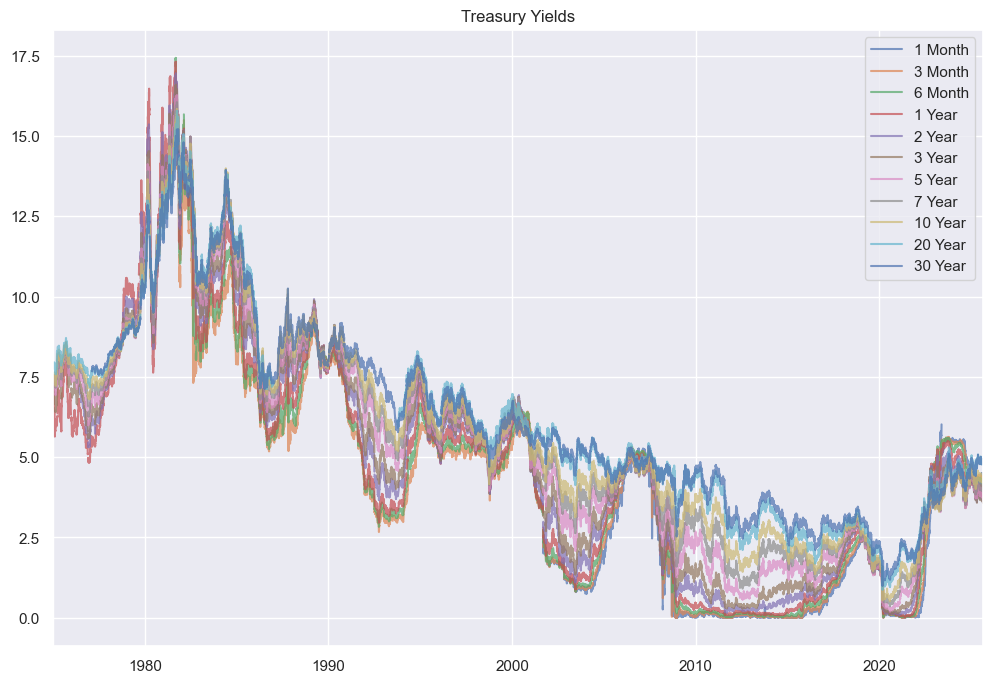

In [9]:
yields.plot(figsize=(12, 8), title='Treasury Yields', alpha=0.7) # Plot the yields
plt.show()

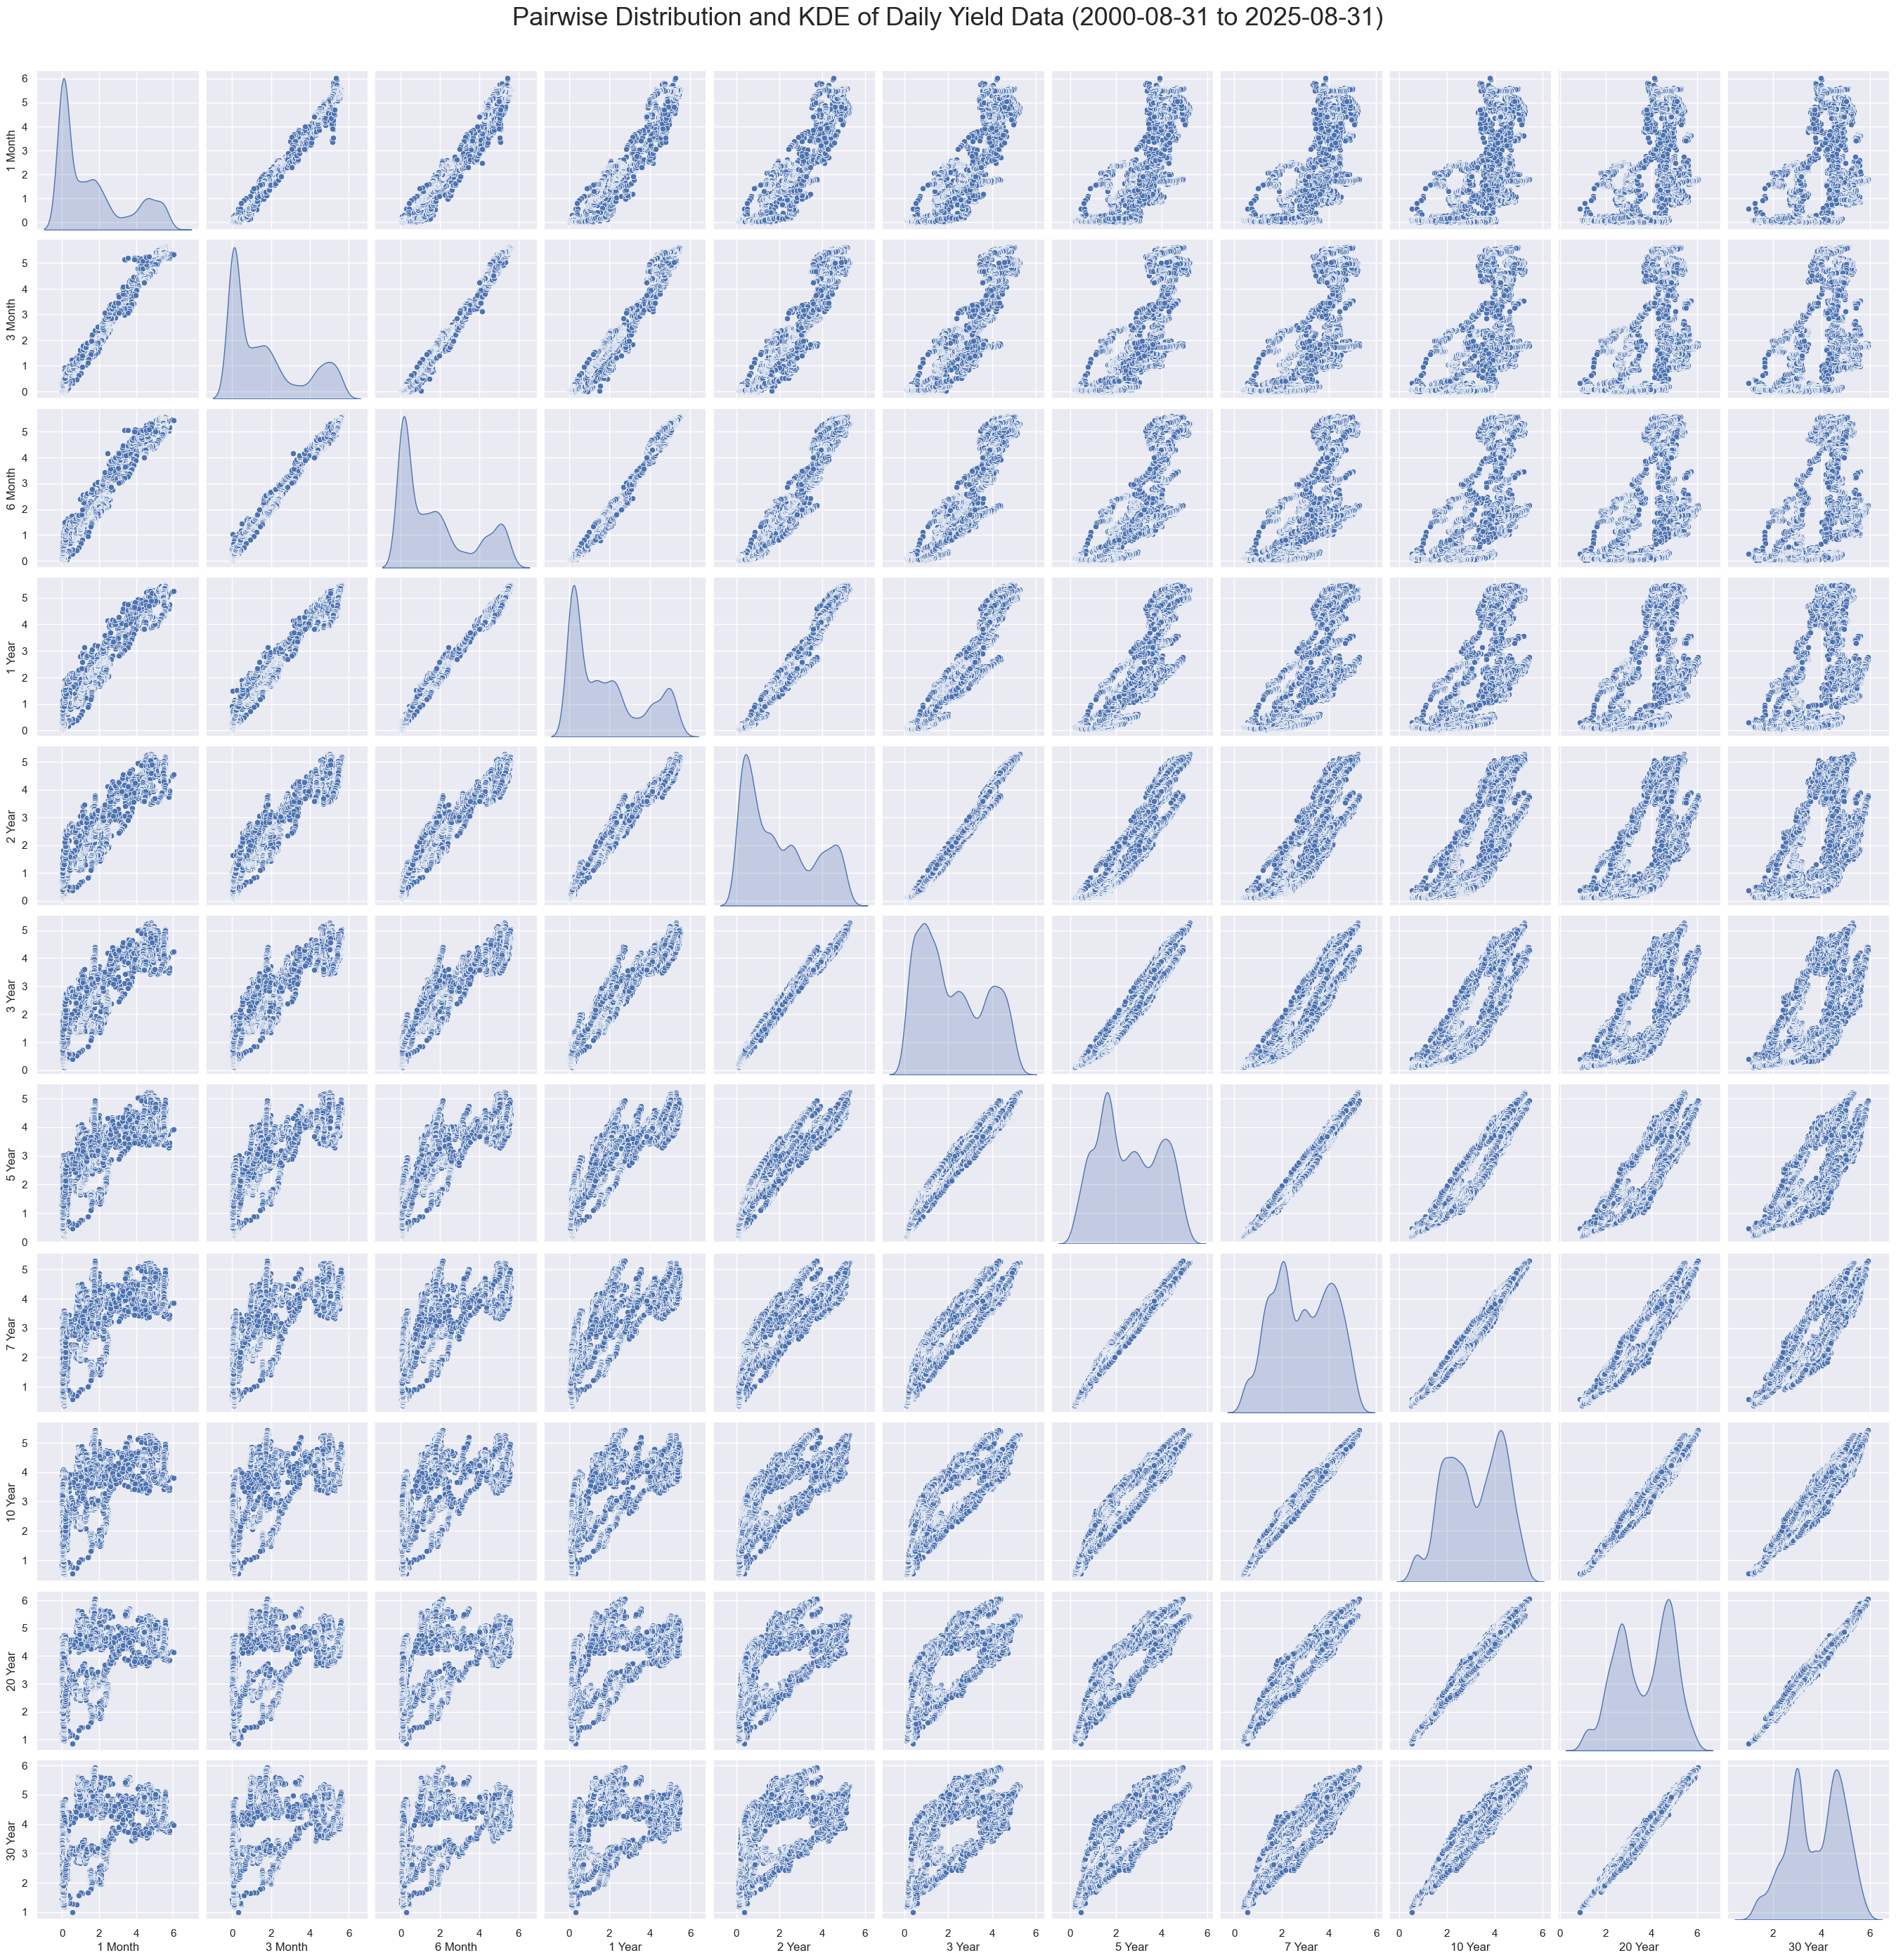

In [14]:
sns.pairplot(yields.dropna(), diag_kind='kde') # Pairplot with KDE on diagonal
plt.suptitle("Pairwise Distribution and KDE of Daily Yield Data (2000-08-31 to 2025-08-31)", y=1.02, fontsize=26)
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\3845187835.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


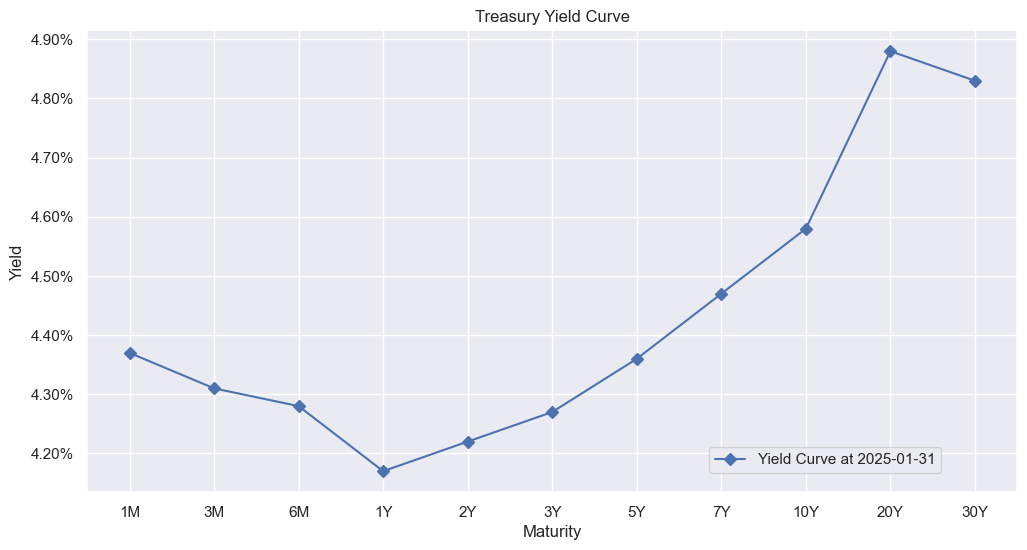

In [21]:
def plot_yield_curve(date):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)
    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title('Treasury Yield Curve') 
    fig.legend(loc = [0.69, 0.14]) # Show the plot
    plt.grid(True)
    plt.show()

plot_yield_curve('2025-01-31')

Slope of the Yield Curve
A positive slope, also referred to as normal yield curve, which occurs when long-term yields are higher than the short-term ones.
A flat slope short-term and long-term yields are similar.
A negative slope, also referred to as inverted yield curve it occurs when short-term yields are higher than long-term ones.

C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\4106215848.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_monthly_bond_market_crash = bond_market_crash.resample('M').last()


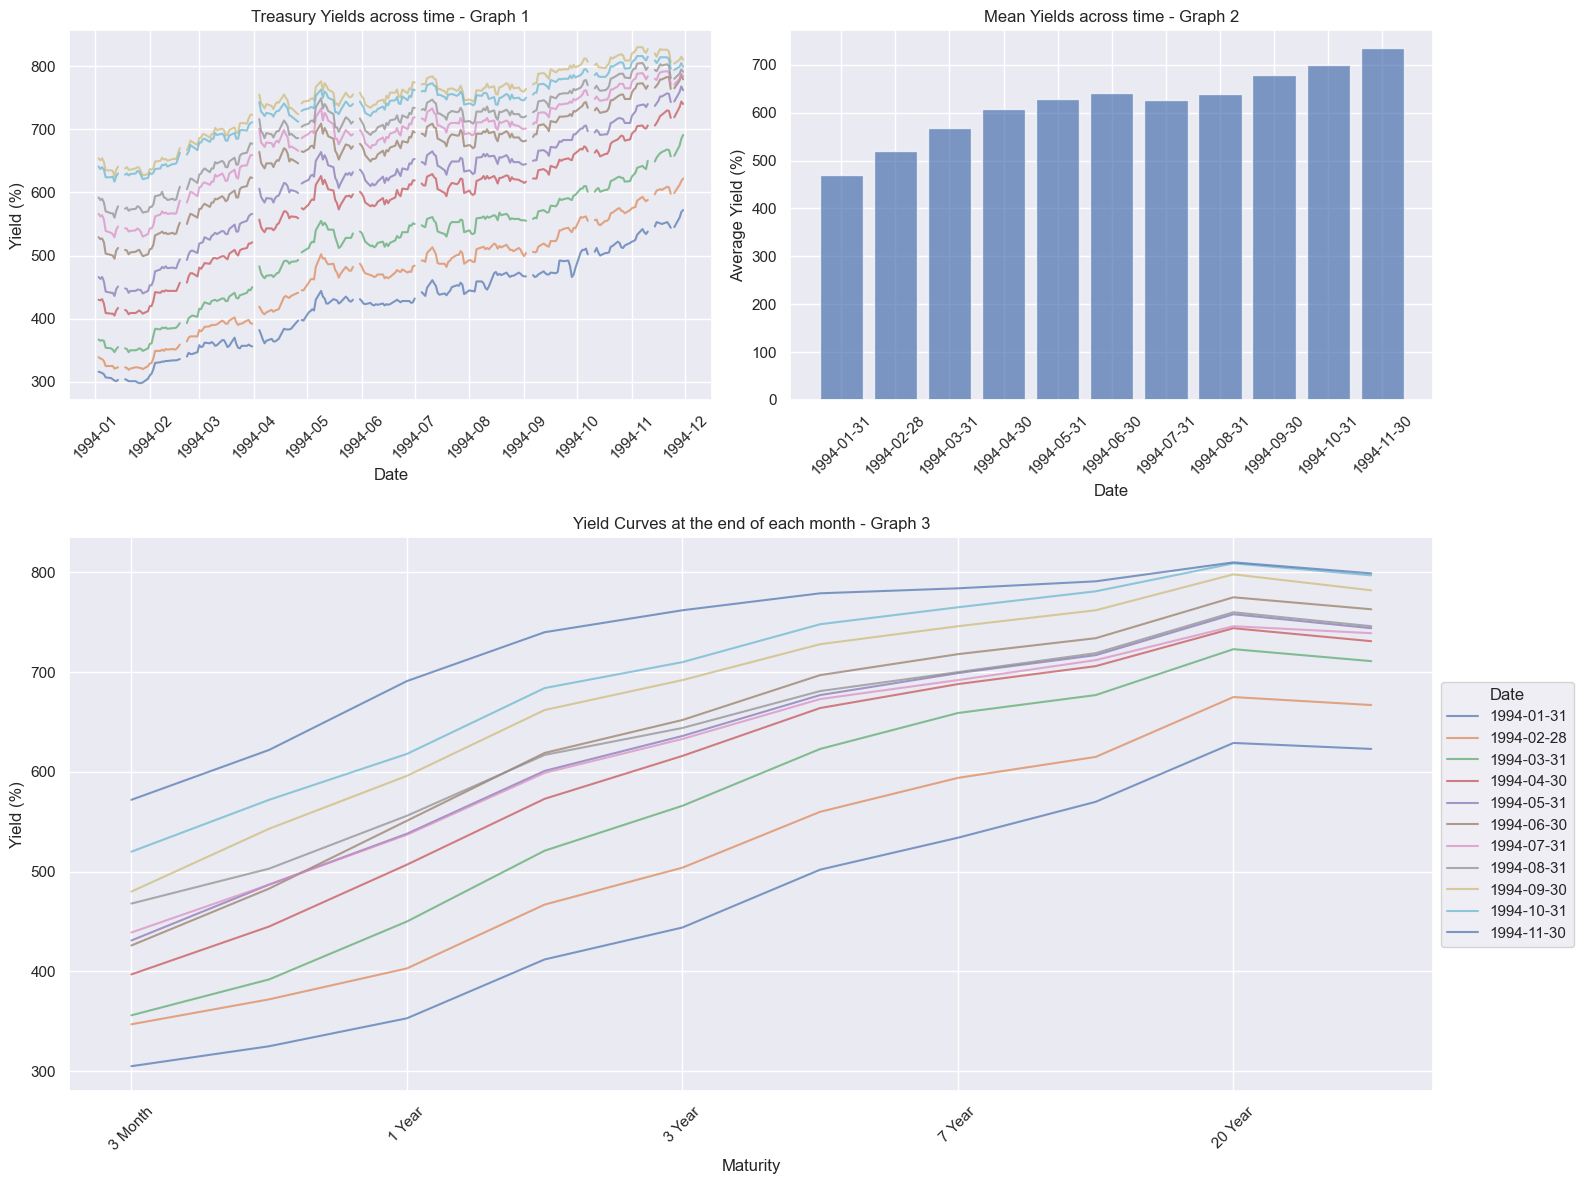

In [22]:
from matplotlib.gridspec import GridSpec
bond_market_crash = yields.loc['1994-01-03': '1994-11-30'].iloc[:,1:] * 100  # Convert yields to percentage
resampled_monthly_bond_market_crash = bond_market_crash.resample('M').last()
resampled_monthly_bond_market_crash_ticks = resampled_monthly_bond_market_crash.index.strftime('%Y-%m-%d')
fig = plt.figure(figsize=(16, 12))    
gs = GridSpec(2, 2, height_ratios=[1, 1.5])

# First row, first column
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(bond_market_crash, alpha=0.7)
ax1.set_title('Treasury Yields across time - Graph 1')
ax1.set_xlabel('Date')
ax1.set_ylabel('Yield (%)')
ax1.tick_params(axis='x', rotation=45)

# First row, second column
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(resampled_monthly_bond_market_crash_ticks, resampled_monthly_bond_market_crash.mean(axis=1), alpha=0.7)
ax2.set_title('Mean Yields across time - Graph 2')
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Yield (%)')
ax2.tick_params(axis='x', rotation=45)

# Second row
ax3 = fig.add_subplot(gs[1, :])
for i in range(len(resampled_monthly_bond_market_crash)):
    date = resampled_monthly_bond_market_crash_ticks[i]
    resampled_monthly_bond_market_crash.iloc[i, :].plot(ax=ax3, alpha=0.7, label=date)

ax3.set_title('Yield Curves at the end of each month - Graph 3')
ax3.set_xlabel('Maturity')
ax3.set_ylabel('Yield (%)')
ax3.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\1080572045.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bear_flattening = yields['2004-06-01':'2006-06-30'].resample('3M').last()
C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\1080572045.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bull_flattening = yields['2010-01-01':'2012-06-30'].resample('4M').last()


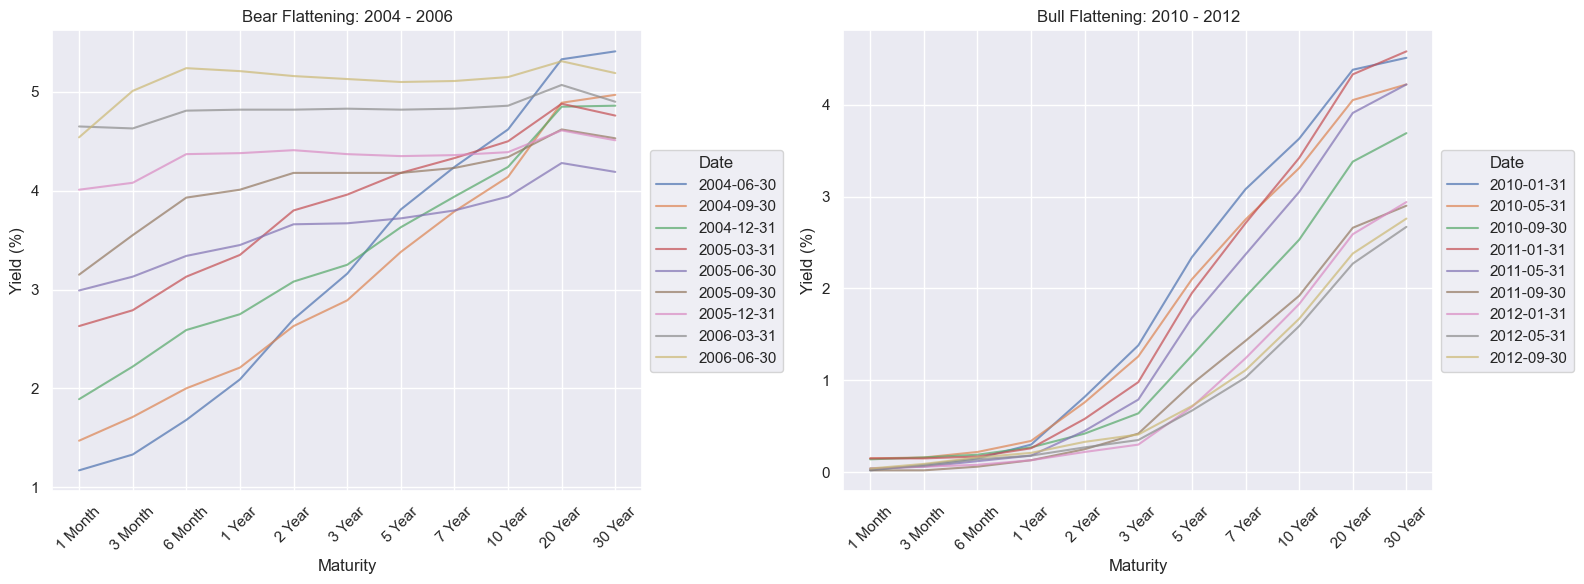

In [23]:
bear_flattening = yields['2004-06-01':'2006-06-30'].resample('3M').last()
bear_flattening.index = bear_flattening.index.strftime('%Y-%m-%d')

bull_flattening = yields['2010-01-01':'2012-06-30'].resample('4M').last()
bull_flattening.index = bull_flattening.index.strftime('%Y-%m-%d')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Bear flattening graph
for i in range(len(bear_flattening)):
    date = bear_flattening.index[i]
    ax1.plot(bear_flattening.columns, bear_flattening.iloc[i, :], alpha=0.7, label=date)
ax1.set_title('Bear Flattening: 2004 - 2006')
ax1.set_xlabel('Maturity')
ax1.set_ylabel('Yield (%)')
ax1.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax1.tick_params(axis='x', rotation=45)
# Bull flattening graph
for i in range(len(bull_flattening)):
    date = bull_flattening.index[i]
    ax2.plot(bull_flattening.columns, bull_flattening.iloc[i, :], alpha=0.7, label=date)
ax2.set_title('Bull Flattening: 2010 - 2012')
ax2.set_xlabel('Maturity')
ax2.set_ylabel('Yield (%)')
ax2.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [26]:
fred = Fred(api_key='53d2b15077e455168b4fa44d3f4899d4')
# Treasury yield seris id
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2025-09-01")
    return data
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}
yields = pd.DataFrame(yields_dict)
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']
yields.index = pd.to_datetime(yields.index)

In [27]:
yields = yields.dropna()#sd of treasury yield for different maturities.
y_std = yields.std()
y_std

1 Month    1.824427
3 Month    1.836730
6 Month    1.826236
1 Year     1.741832
2 Year     1.585510
3 Year     1.475632
5 Year     1.323605
7 Year     1.232871
10 Year    1.174677
20 Year    1.197849
30 Year    1.098160
dtype: float64

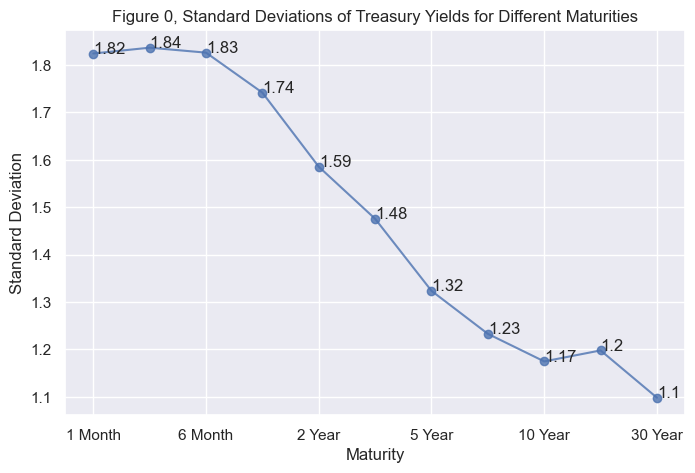

In [28]:
fig, ax = plt.subplots()
y_std.plot(figsize = (8,5),marker='o', title='Figure 0, Standard Deviations of Treasury Yields for Different Maturities', alpha=0.8) # Plot sd of yields of different maturies
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")
for i in range(len(y_std)):
    ax.annotate(str(round(y_std.iloc[i],2)),xy=(i,y_std.iloc[i]))
plt.show()

 Polynomial Fitting for U.S. Treasury Yield Curve

Figure 3


C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\1199941227.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


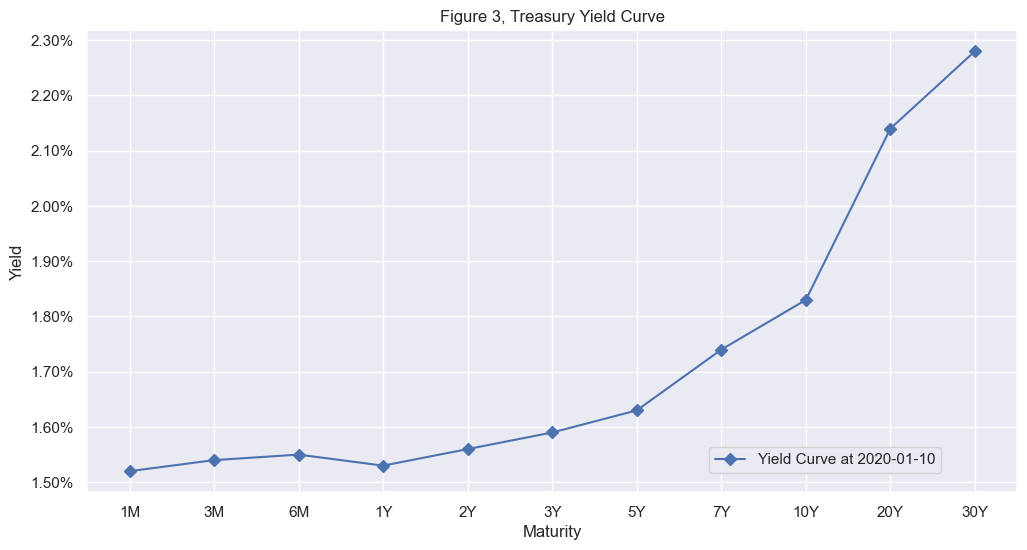

In [29]:
def plot_yield_curve(date, fig_n):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)
    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'Treasury Yield Curve')
    fig.legend(loc = [0.69, 0.14])
    plt.grid(True)
    plt.show()

print("Figure 3")
plot_yield_curve('2020-01-10','Figure 3, ')

In [30]:
pip install nelson_siegel_svensson


   ---------------------------------------- 0/2 [Click]
   ---------------------------------------- 0/2 [Click]
   ---------------------------------------- 0/2 [Click]
   -------------------- ------------------- 1/2 [nelson_siegel_svensson]
   -------------------- ------------------- 1/2 [nelson_siegel_svensson]
   ---------------------------------------- 2/2 [nelson_siegel_svensson]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import numpy as np

In [35]:
t = np.array([0.08333,0.25,0.5,1,2,3,5,7,10,20,30])
y = np.array(yields.loc["2020-01-10"])

In [36]:
curve, status = calibrate_ns_ols(t, y, tau0=1.0)  # starting value of 1.0 for the optimization of tau
assert status.success
print(curve)

NelsonSiegelCurve(beta0=np.float64(2.6376805011083615), beta1=np.float64(-1.1025855357123264), beta2=np.float64(-1.1406474779544136), tau=np.float64(4.750012469139109))


Text(0.5, 1.0, 'Figure 4, NS Model Result')

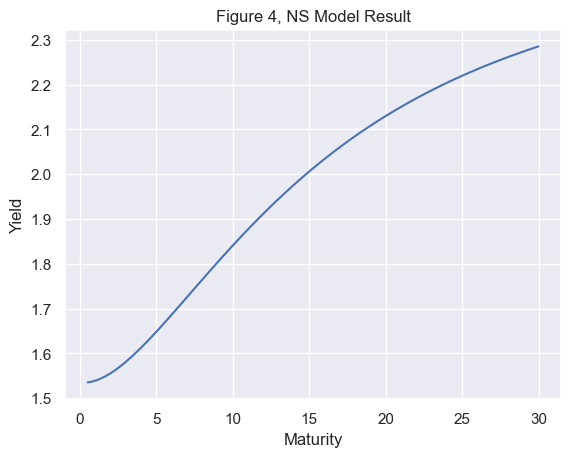

In [37]:
y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 4, NS Model Result")

C:\Users\ankit\AppData\Local\Temp\ipykernel_19636\1199941227.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


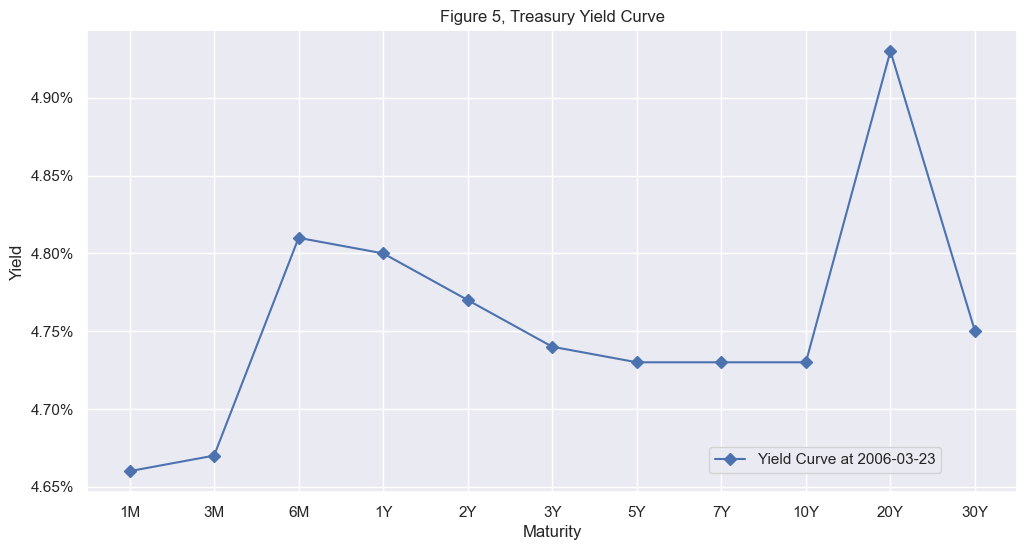

In [38]:
plot_yield_curve('2006-03-23','Figure 5, ')

In [39]:
yields.loc["2020-01-10"]

1 Month    1.52
3 Month    1.54
6 Month    1.55
1 Year     1.53
2 Year     1.56
3 Year     1.59
5 Year     1.63
7 Year     1.74
10 Year    1.83
20 Year    2.14
30 Year    2.28
Name: 2020-01-10 00:00:00, dtype: float64

In [40]:
t = np.array([2,5,10,30])
y = np.array([1.56,1.63,1.83,2.28])

In [42]:
# Create output vector y (ovariable) and squared matrix A (ivariable)
out = np.array([1.56,1.63,1.63,1.83,1.83,2.28,0,0,0,0,0,0])
input = np.array([[8,4,2,1,0,0,0,0,0,0,0,0],[125,25,5,1,0,0,0,0,0,0,0,0],[0,0,0,0,125,25,5,1,0,0,0,0],[0,0,0,0,1000,100,10,1,0,0,0,0], \
                  [0,0,0,0,0,0,0,0,1000,100,10,1],[0,0,0,0,0,0,0,0,27000,900,30,1],[75,10,1,0,-75,-10,-1,0,0,0,0,0],[0,0,0,0,300,20,1,0,-300,-20,-1,0], \
                  [30,2,0,0,-30,-2,0,0,0,0,0,0],[0,0,0,0,60,2,0,0,-60,-2,0,0],[12,2,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,180,2,0,0]])
# Solve for coefficient vector and reshape to an 3 by 4 array (lines variable)
lines = np.round(np.dot(np.linalg.inv(input), out).reshape(-1,4),decimals=8)
lines


array([[ 3.96060000e-04, -2.37634000e-03,  2.45215100e-02,
         1.51729391e+00],
       [-3.31400000e-04,  8.53548000e-03, -3.00376300e-02,
         1.60822581e+00],
       [ 2.34400000e-05, -2.10968000e-03,  7.64139800e-02,
         1.25338710e+00]])

In [49]:
# Calculates x**0 + x**1 + x**2 + x**3
def plot_num(values, coeffs):
    expanded = np.hstack([coeffs[i] * (values ** i) for i in range(0, len(coeffs))])# Coeffs are assumed to be in order 0, 1, ..., n-1
    return np.sum(expanded, axis=1)

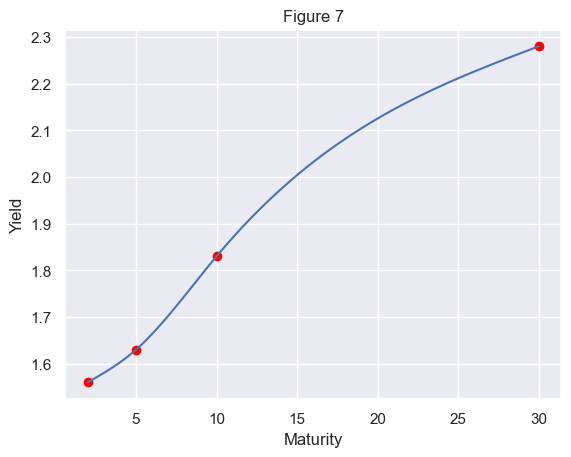

In [50]:
xs = np.linspace(2,30, 100)
y1s = plot_num(xs[xs<5].reshape(-1,1), lines[0][::-1])
y2s = plot_num(xs[(xs>=5) & (xs<10)].reshape(-1,1), lines[1][::-1])
y3s = plot_num(xs[xs>=10].reshape(-1,1), lines[2][::-1])
ys = np.concatenate([y1s, y2s, y3s])
plt.plot(xs, ys)
plt.scatter(t, y,c="red")
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 7")
plt.show()